In [26]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt


In [27]:
class ChebyshevLayer(layers.Layer):
    def __init__(self, units, degree, **kwargs):
        super(ChebyshevLayer, self).__init__(**kwargs)
        self.units = units
        self.degree = degree

    def build(self, input_shape):
        # Pesos para cada grado del polinomio
        self.w = self.add_weight(
            shape=(self.degree + 1, input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="chebyshev_weights"
        )

    def call(self, inputs):
        # Valores iniciales de la recurrencia de Chebyshev
        # T0(x) = 1
        previous_previous_poly = tf.ones_like(inputs)

        # T1(x) = x
        previous_poly = inputs

        # Salida inicial con los dos primeros grados
        output_values = (
            tf.matmul(previous_previous_poly, self.w[0]) +
            tf.matmul(previous_poly, self.w[1])
        )

        # Aqui de forma recursiva generamos los otros grados 
        for degree_index in range(2, self.degree + 1):
            current_poly = 2.0 * inputs * previous_poly - previous_previous_poly

            output_values += tf.matmul(current_poly, self.w[degree_index])

            # Preparamos la siguiente iteración
            previous_previous_poly = previous_poly
            previous_poly = current_poly

        return output_values

In [28]:
#Ahora debemos debemos de crear una función para dibujar la grafica de entrenamiento
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    
    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    


In [29]:
#Cargamos los datos del Dataset.
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 


#Separamos el dataset en entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

#Normalizamos los datos para que el entrenamiento sea más eficiente entre -1 y 1
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train.shape[1]


#Cambiamos las etiquetas a 0 y 1
y_train = (y_train == 'g').astype(int)
y_test = (y_test == 'g').astype(int)


In [30]:
def build_chebyshev_model(degree, input_dim):
    inputs = keras.Input(shape=(input_dim,))
    x = ChebyshevLayer(32, degree=degree)(inputs)
    x = layers.Activation("swish")(x)
    x = layers.Dense(16, activation="swish")(x)
    outputs = layers.Dense(2, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [31]:
#Parametros para el entrenamiento
degree = 4
epochs = 120


In [32]:
def createEarlyStoppingCallback(patience=15):
    return keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

In [33]:
#importamos para ir borrando el historial de entrenamiento y así evitar que se sobreescriba el mismo historial en cada modelo
from keras import backend as K

# --- Entrenamiento Grado 2 ---
K.clear_session()  # Limpiamos la sesión para evitar que los modelos compartan pesos o historial
print("Entrenando Grado" + str(degree) + " ...")
modeloTest = build_chebyshev_model(degree=degree, input_dim=input_dim)
history = modeloTest.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)


Entrenando Grado4 ...
Epoch 1/120
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7939 - loss: 0.4477 - val_accuracy: 0.8310 - val_loss: 0.3841
Epoch 2/120
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8477 - loss: 0.3711 - val_accuracy: 0.8457 - val_loss: 0.3635
Epoch 3/120
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8507 - loss: 0.3594 - val_accuracy: 0.8460 - val_loss: 0.3528
Epoch 4/120
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8506 - loss: 0.3541 - val_accuracy: 0.8457 - val_loss: 0.3505
Epoch 5/120
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8547 - loss: 0.3475 - val_accuracy: 0.8535 - val_loss: 0.3425
Epoch 6/120
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8553 - loss: 0.3444 - val_accuracy: 0.8494 - val_loss: 0.3530
Epoch 7/120
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8579 - loss: 0.3423 - val_accuracy: 0.8551 - val_loss: 0.3354
Epoch 8/120
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8579 - l


RESULTADOS FINALES (Grado 4)
Acurracy en test: 0.881528


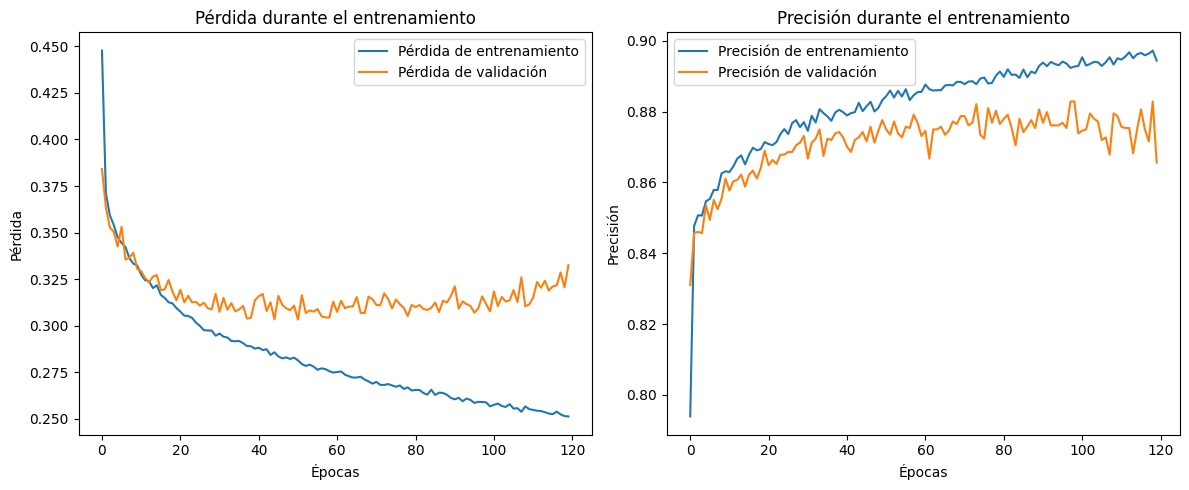

In [34]:
print("\n" + "="*40)
print(f"RESULTADOS FINALES (Grado {degree})")
print("Acurracy en test: {:.6f}".format(modeloTest.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history)